<a href="https://colab.research.google.com/github/mapurva/CodeWorkspace/blob/main/Markov_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markov Chains: Theory, Simulation, and Applications


## 🎯 Learning Outcomes
By the end, you should be able to:
- Explain the Markov Property formally
- Work with transition matrices
- Simulate Markov processes
- Compute steady-state distributions
- Analyze real-world systems using Markov chains

## What is a Markov Chain?

A Markov Chain is a stochastic process satisfying:

$[
P(X_{n+1} = j \mid X_n = i, X_{n-1}, \dots, X_0)
= P(X_{n+1} = j \mid X_n = i)
$]

### 🔑 Key Idea:
The **future depends only on the present**, not the past.

---

### 🤔 Think Before Moving On
- Can you think of a real-life system where history does NOT matter?
- Can you think of one where it DOES?

## Transition Matrix

A Markov Chain with finite states can be represented using a matrix:

$[
P =
\begin{bmatrix}
0.7 & 0.3 \\
0.4 & 0.6
\end{bmatrix}
$]

Where:
- Row = current state
- Column = next state
- Each row sums to 1

---

### 🤔 Check Yourself
- Why must each row sum to 1?

In [1]:
import numpy as np

# Transition matrix
P = np.array([[0.7, 0.3],
              [0.4, 0.6]])

# Initial state: fully in state S1
state = np.array([1, 0])

print("Initial State:", state)

for step in range(5):
    state = state @ P  # Matrix multiplication
    print(f"After step {step+1}: {state}")

Initial State: [1 0]
After step 1: [0.7 0.3]
After step 2: [0.61 0.39]
After step 3: [0.583 0.417]
After step 4: [0.5749 0.4251]
After step 5: [0.57247 0.42753]


### 🧠 What just happened?

We computed:

$[
\text{state}_{t+1} = \text{state}_t \cdot P
$]

---

### 🤔 Think
- Why are we multiplying from the left?
- What does each value in the state vector represent?

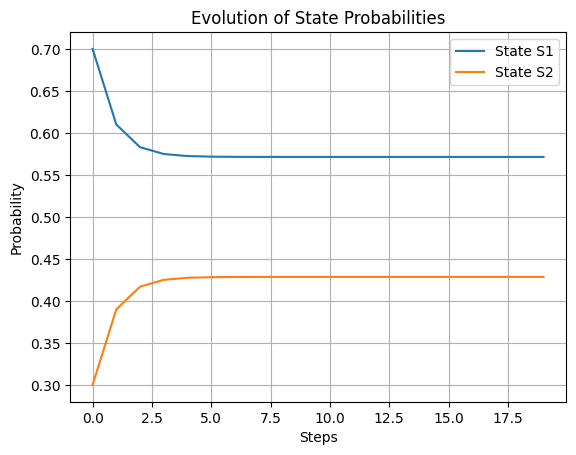

In [2]:
import matplotlib.pyplot as plt

state = np.array([1, 0])
history = []

for _ in range(20):
    state = state @ P
    history.append(state.copy())

history = np.array(history)

plt.plot(history[:, 0], label="State S1")
plt.plot(history[:, 1], label="State S2")
plt.xlabel("Steps")
plt.ylabel("Probability")
plt.title("Evolution of State Probabilities")
plt.legend()
plt.grid()
plt.show()

### 🔍 Observe
- Do the probabilities stabilize?
- Do they depend on the initial state?

This leads to the idea of **steady-state distribution**.

## Steady-State Distribution

A vector $( \pi $) is steady-state if:

$[
\pi P = \pi
$]

---

### Interpretation:
Once reached, the system **stops changing**.

In [3]:
eigvals, eigvecs = np.linalg.eig(P.T)

steady_state = eigvecs[:, np.isclose(eigvals, 1)]
steady_state = steady_state[:, 0]
steady_state = steady_state / np.sum(steady_state)

print("Steady-state distribution:", steady_state.real)

Steady-state distribution: [0.57142857 0.42857143]


### 🤔 Think
- Why eigenvalue = 1?
- Is steady-state always guaranteed?

## Weather Model

States:
- Sunny
- Rainy

$[
P =
\begin{bmatrix}
0.8 & 0.2 \\
0.5 & 0.5
\end{bmatrix}
$]

In [4]:
P = np.array([[0.8, 0.2],
              [0.5, 0.5]])

state = np.array([1, 0])  # Start Sunny

for i in range(10):
    state = state @ P
    print(f"Day {i+1}: {state}")

Day 1: [0.8 0.2]
Day 2: [0.74 0.26]
Day 3: [0.722 0.278]
Day 4: [0.7166 0.2834]
Day 5: [0.71498 0.28502]
Day 6: [0.714494 0.285506]
Day 7: [0.7143482 0.2856518]
Day 8: [0.71430446 0.28569554]
Day 9: [0.71429134 0.28570866]
Day 10: [0.7142874 0.2857126]


### 🤔 Think
- Will it always converge?
- What does steady-state mean here physically?

## Absorbing State

A state \( i \) is absorbing if:

$[
P(i \to i) = 1
$]

---

### Example:
$[
P =
\begin{bmatrix}
1 & 0 \\
0.3 & 0.7
\end{bmatrix}
$]

In [5]:
P = np.array([[1.0, 0.0],
              [0.3, 0.7]])

state = np.array([0, 1])

for i in range(10):
    state = state @ P
    print(f"Step {i+1}: {state}")

Step 1: [0.3 0.7]
Step 2: [0.51 0.49]
Step 3: [0.657 0.343]
Step 4: [0.7599 0.2401]
Step 5: [0.83193 0.16807]
Step 6: [0.882351 0.117649]
Step 7: [0.9176457 0.0823543]
Step 8: [0.94235199 0.05764801]
Step 9: [0.95964639 0.04035361]
Step 10: [0.97175248 0.02824752]


### 🔍 Observe
- What happens to probability mass over time?

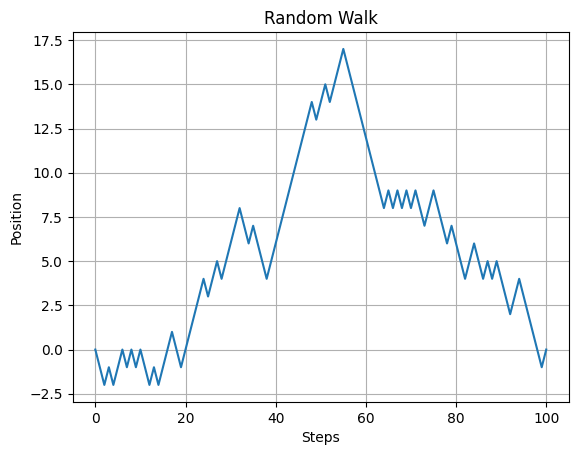

In [6]:
#Random walk
import random

def random_walk(steps=100):
    pos = 0
    positions = [pos]

    for _ in range(steps):
        pos += random.choice([-1, 1])
        positions.append(pos)

    return positions

walk = random_walk()

plt.plot(walk)
plt.title("Random Walk")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.grid()
plt.show()

### 🔗 Connection to CS
- Graph traversal
- PageRank
- Reinforcement Learning

## 🧪 Exercises

### Level 1 (Understanding)
- Change transition probabilities. What changes?
- Try a different initial state.

---

### Level 2 (Analysis)
- Create a 3-state Markov chain
- Check if it converges

---

### Level 3 (Design)
- Design an absorbing chain with 3 states
- Explain its behavior

---

### Level 4 (Deep Thinking)
- Can different matrices have same steady-state?
- When does convergence fail?

## 🧠 Reflection

- Where is the Markov assumption unrealistic?
- How would you extend this to Hidden Markov Models?
- How is this useful in Machine Learning?

---

## 🚀 Extension
Explore:
- PageRank
- Hidden Markov Models
- Markov Decision Processes